# 02 — Análise Exploratória de Dados (EDA)

**Objetivo:** Entender o perfil dos acidentes em Niterói/RJ através de estatísticas descritivas e visualizações. Identificar padrões temporais, causas e tipos mais frequentes.

---

## 0. Imports e Configurações

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
AZUL = '#1a6faf'

# Carrega dados limpos
df = pd.read_csv('../data/processed/acidentes_niteroi_limpo.csv',
                 parse_dates=['data'], low_memory=False)

print(f'Dataset carregado: {df.shape[0]:,} registros | {df.shape[1]} colunas')
df.head(3)

Dataset carregado: 4,320 registros | 37 colunas


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,regional,delegacia,uop,ano_arquivo,data,hora,ano,mes,dia_semana_nome,gravidade
0,261110.0,2020-01-06,0.0,01:05:00,RJ,101,322,NITEROI,FALTA DE ATENÇÃO À CONDUÇÃO,COLISÃO COM OBJETO ESTÁTICO,...,SPRF-RJ,DEL02-RJ,UOP01-DEL02-RJ,2020,2020-06-01,1,2020.0,6.0,Segunda,0.0
1,261809.0,2020-01-09,1.0,23:30:00,RJ,101,"309,4",SAO GONCALO,AGRESSÃO EXTERNA,COLISÃO COM OBJETO ESTÁTICO,...,SPRF-RJ,DEL02-RJ,UOP02-DEL02-RJ,2020,2020-09-01,23,2020.0,9.0,Terça,1.0
2,263611.0,2020-01-18,NaN,14:10:00,RJ,493,"0,7",SAO GONCALO,FALTA DE ATENÇÃO À CONDUÇÃO,COLISÃO TRASEIRA,...,SPRF-RJ,DEL02-RJ,UOP02-DEL02-RJ,2020,NaT,14,NaN,NaN,NaN,1.0


## 1. Estatísticas Gerais

In [33]:
print('=== RESUMO GERAL ===')
print(f'Total de acidentes:     {len(df):,}')
print(f'Período:                {df["data"].min().date()} → {df["data"].max().date()}')
print(f'Municípios:             {df["municipio"].nunique()}')

if 'mortos' in df.columns:
    print(f'Total de mortos:        {df["mortos"].sum():,.0f}')
if 'feridos_graves' in df.columns:
    print(f'Feridos graves:         {df["feridos_graves"].sum():,.0f}')
if 'feridos_leves' in df.columns:
    print(f'Feridos leves:          {df["feridos_leves"].sum():,.0f}')

=== RESUMO GERAL ===
Total de acidentes:     4,320
Período:                2020-01-01 → 2026-12-02
Municípios:             4
Total de mortos:        197
Feridos graves:         573
Feridos leves:          3,994


## 2. Acidentes ao Longo do Tempo

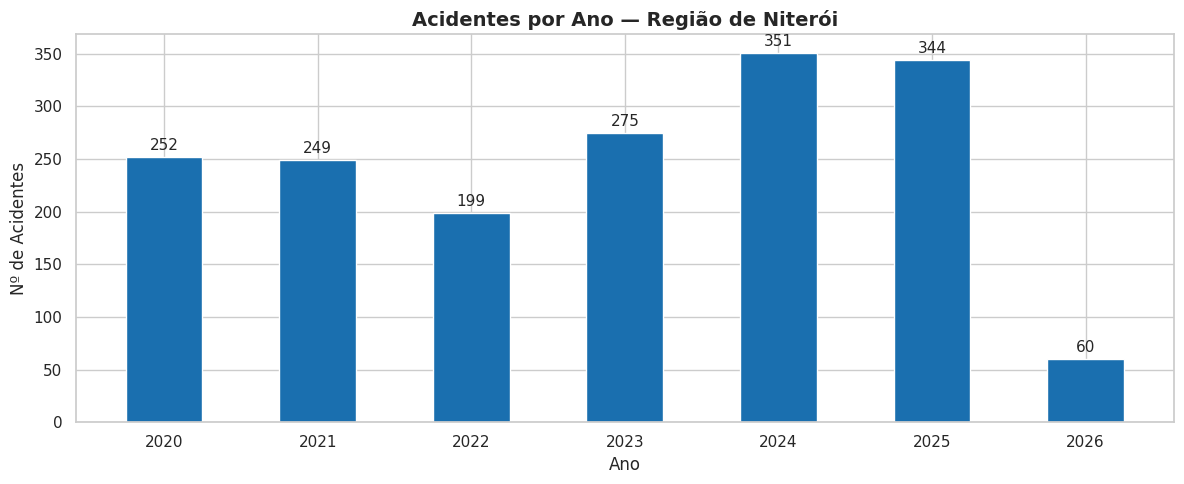

In [34]:
# Acidentes por ano
por_ano = df.groupby('ano').size().reset_index(name='acidentes')
por_ano = por_ano.dropna(subset=['ano'])
por_ano['ano'] = por_ano['ano'].astype(int)

fig, ax = plt.subplots()
bars = ax.bar(por_ano['ano'], por_ano['acidentes'], color=AZUL, edgecolor='white', width=0.5)
ax.bar_label(bars, padding=3, fontsize=11)
ax.set_title('Acidentes por Ano — Região de Niterói', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Nº de Acidentes')
ax.set_xticks(por_ano['ano'])
plt.tight_layout()
plt.savefig('../outputs/acidentes_por_ano.png', dpi=150)
plt.show()

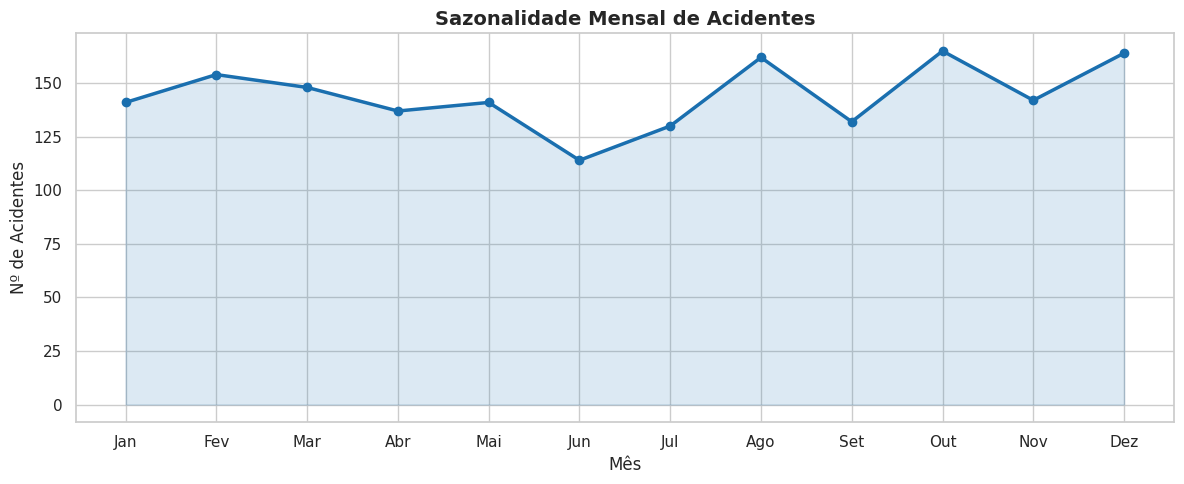

In [35]:
# Sazonalidade: acidentes por mês
meses_nomes = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
por_mes = df.groupby('mes').size().reset_index(name='acidentes')
por_mes['mes_nome'] = por_mes['mes'].apply(lambda x: meses_nomes[int(x)-1])

fig, ax = plt.subplots()
ax.plot(por_mes['mes'], por_mes['acidentes'], marker='o', color=AZUL, linewidth=2.5)
ax.fill_between(por_mes['mes'], por_mes['acidentes'], alpha=0.15, color=AZUL)
ax.set_xticks(por_mes['mes'])
ax.set_xticklabels(por_mes['mes_nome'])
ax.set_title('Sazonalidade Mensal de Acidentes', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Nº de Acidentes')
plt.tight_layout()
plt.savefig('../outputs/acidentes_por_mes.png', dpi=150)
plt.show()

## 3. Padrões Temporais Detalhados

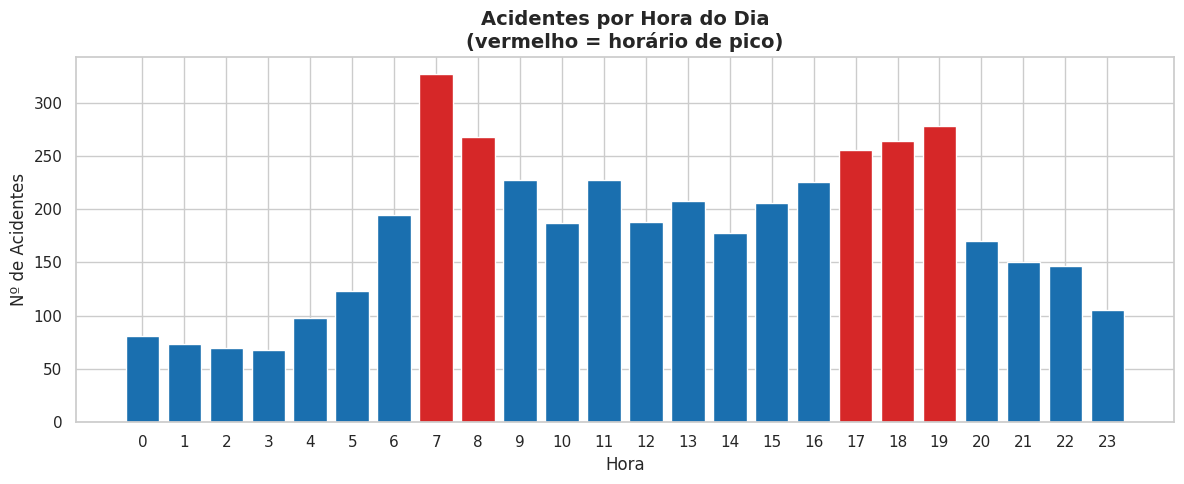

Hora com mais acidentes: 7h


In [36]:
# Acidentes por hora do dia
if 'hora' in df.columns:
    por_hora = df.groupby('hora').size().reset_index(name='acidentes')

    fig, ax = plt.subplots()
    colors = ['#d62728' if h in [7,8,17,18,19] else AZUL for h in por_hora['hora']]
    ax.bar(por_hora['hora'], por_hora['acidentes'], color=colors, edgecolor='white')
    ax.set_title('Acidentes por Hora do Dia\n(vermelho = horário de pico)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Hora')
    ax.set_ylabel('Nº de Acidentes')
    ax.set_xticks(range(0, 24))
    plt.tight_layout()
    plt.savefig('../outputs/acidentes_por_hora.png', dpi=150)
    plt.show()

    hora_pico = por_hora.loc[por_hora['acidentes'].idxmax(), 'hora']
    print(f'Hora com mais acidentes: {hora_pico}h')

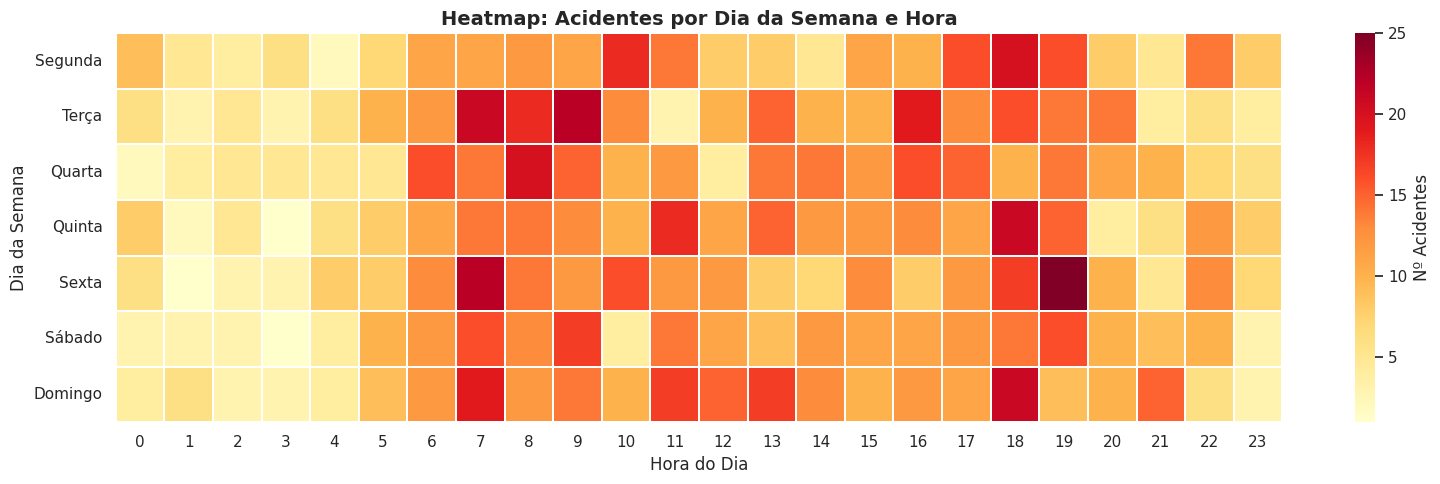

In [37]:
# Heatmap: dia da semana x hora
if 'hora' in df.columns:
    dias = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado','Domingo']
    pivot = df.groupby(['dia_semana', 'hora']).size().unstack(fill_value=0)
    pivot.index = dias[:len(pivot)]

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=ax, cbar_kws={'label': 'Nº Acidentes'})
    ax.set_title('Heatmap: Acidentes por Dia da Semana e Hora', fontsize=14, fontweight='bold')
    ax.set_xlabel('Hora do Dia')
    ax.set_ylabel('Dia da Semana')
    plt.tight_layout()
    plt.savefig('../outputs/heatmap_dia_hora.png', dpi=150)
    plt.show()

## 4. Causas e Tipos de Acidente

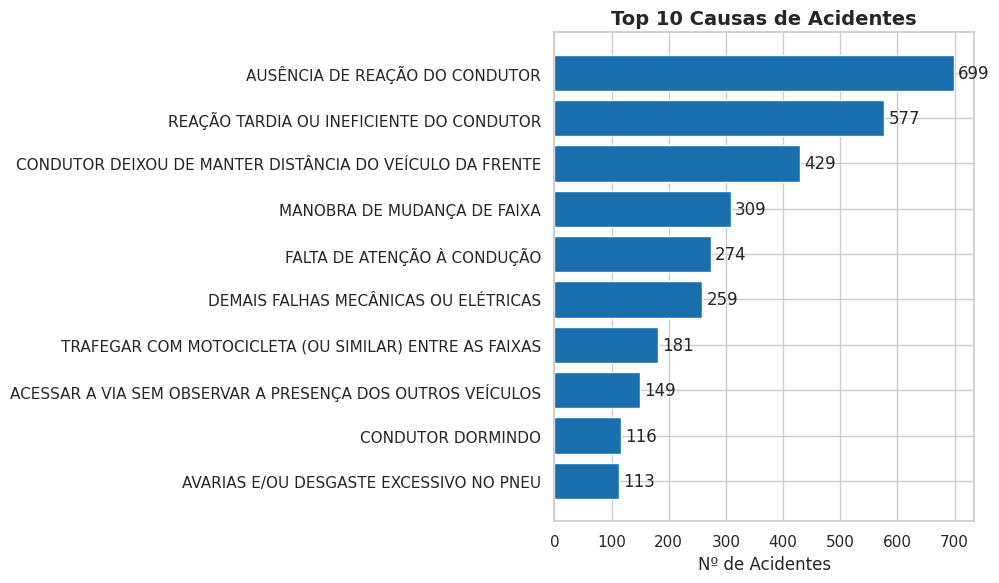

In [38]:
# Top 10 causas
if 'causa_acidente' in df.columns:
    top_causas = df['causa_acidente'].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_causas.index[::-1], top_causas.values[::-1], color=AZUL)
    ax.bar_label(bars, padding=3)
    ax.set_title('Top 10 Causas de Acidentes', fontsize=14, fontweight='bold')
    ax.set_xlabel('Nº de Acidentes')
    plt.tight_layout()
    plt.savefig('../outputs/top_causas.png', dpi=150)
    plt.show()

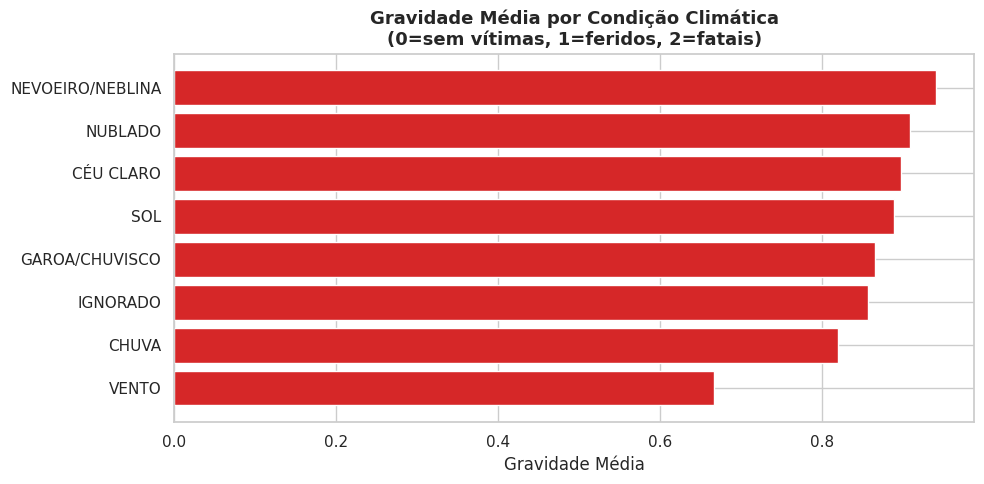

In [39]:
# Gravidade por condição meteorológica
if 'condicao_metereologica' in df.columns and 'gravidade' in df.columns:
    clima_gravidade = df.groupby('condicao_metereologica')['gravidade'].mean().sort_values(ascending=False).head(8)

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#d62728' if v > 0.5 else AZUL for v in clima_gravidade.values]
    bars = ax.barh(clima_gravidade.index[::-1], clima_gravidade.values[::-1], color=colors[::-1])
    ax.set_title('Gravidade Média por Condição Climática\n(0=sem vítimas, 1=feridos, 2=fatais)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gravidade Média')
    plt.tight_layout()
    plt.savefig('../outputs/gravidade_por_clima.png', dpi=150)
    plt.show()

## 5. Correlações e Insights Finais

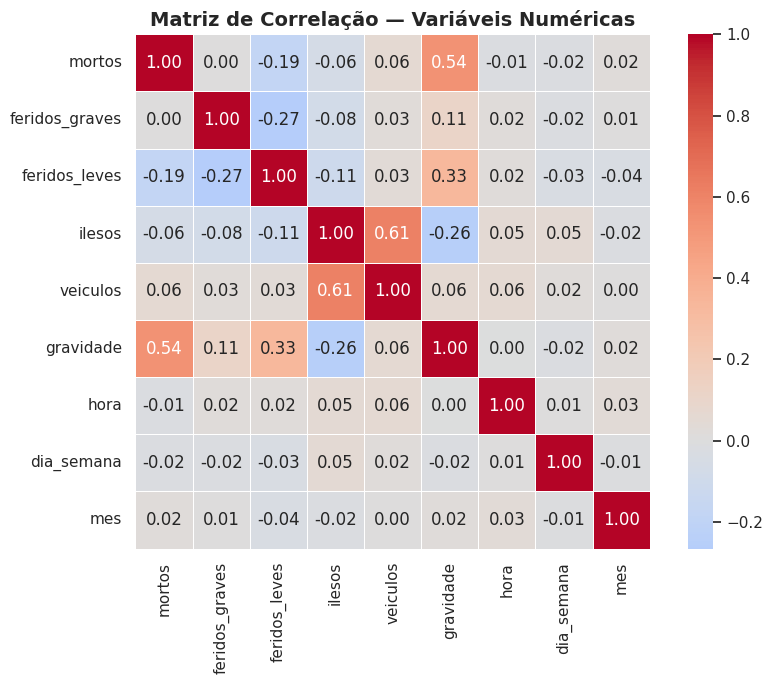

In [40]:
# Colunas numéricas para correlação
cols_num = ['mortos','feridos_graves','feridos_leves','ilesos','veiculos','gravidade','hora','dia_semana','mes']
cols_num = [c for c in cols_num if c in df.columns]

if len(cols_num) >= 3:
    corr = df[cols_num].corr()

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Matriz de Correlação — Variáveis Numéricas', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../outputs/correlacao.png', dpi=150)
    plt.show()

In [41]:
print('=== INSIGHTS PRINCIPAIS ===')
print()

if 'hora' in df.columns:
    hora_pico = df.groupby('hora').size().idxmax()
    print(f'⏰ Hora com mais acidentes: {hora_pico}h')

if 'dia_semana_nome' in df.columns:
    dia_pico = df['dia_semana_nome'].value_counts().idxmax()
    print(f'📅 Dia com mais acidentes: {dia_pico}')

if 'causa_acidente' in df.columns:
    causa_top = df['causa_acidente'].value_counts().idxmax()
    print(f'⚠️ Causa mais comum: {causa_top}')

if 'gravidade' in df.columns:
    pct_fatal = (df['gravidade'] == 2).mean() * 100
    print(f'💀 Acidentes fatais: {pct_fatal:.1f}% do total')

=== INSIGHTS PRINCIPAIS ===

⏰ Hora com mais acidentes: 7h
📅 Dia com mais acidentes: Terça
⚠️ Causa mais comum: AUSÊNCIA DE REAÇÃO DO CONDUTOR
💀 Acidentes fatais: 4.3% do total
